In [2]:
import pandas as pd
from IPython.display import display

df = pd.read_csv("inp1.csv")

# 2) Parse datetime + clean sales

df["datetime"] = pd.to_datetime(
    df["Date and time"],
    format="%m/%d/%Y %I:%M:%S %p",
    errors="coerce"
)

# Convert sales to numeric 
df["Retail at Sale"] = pd.to_numeric(df["Retail at Sale"], errors="coerce").fillna(0)

# Drop rows where datetime is missing (bad parse or blank rows)
df = df.dropna(subset=["datetime"])


# 3) Create grouping fields

df["sale_date"] = df["datetime"].dt.floor("D")
df["month"] = df["datetime"].dt.to_period("M").astype(str)  
df["weekday"] = df["datetime"].dt.day_name()             
df["hour"] = df["datetime"].dt.hour                          

# 4) DAILY hourly totals (Sales)
#    (sum per day per hour)
daily_hourly_sales = (
    df.groupby(["month", "weekday", "sale_date", "hour"], as_index=False)["Retail at Sale"]
      .sum()
      .rename(columns={"Retail at Sale": "hourly_sales"})
)

# ----------------------------
# 5) DAILY hourly totals (Customers)
#    (unique Tran ID per day per hour)
# ----------------------------
daily_hourly_customers = (
    df.groupby(["month", "weekday", "sale_date", "hour"], as_index=False)["Tran ID"]
      .nunique()
      .rename(columns={"Tran ID": "customer_visits"})
)

# ----------------------------
# 6) Average across days (Sales + Customers)
# ----------------------------
avg_sales = (
    daily_hourly_sales.groupby(["month", "weekday", "hour"], as_index=False)["hourly_sales"]
      .mean()
      .rename(columns={"hourly_sales": "avg_hourly_sales"})
)

avg_customers = (
    daily_hourly_customers.groupby(["month", "weekday", "hour"], as_index=False)["customer_visits"]
      .mean()
      .rename(columns={"customer_visits": "avg_customer_visits"})
)

# ----------------------------
# 7) Combine sales + customers
# ----------------------------
combined = avg_sales.merge(
    avg_customers,
    on=["month", "weekday", "hour"],
    how="inner"
)

# Helpful extra metrics
combined["sales_per_customer"] = combined["avg_hourly_sales"] / combined["avg_customer_visits"].replace(0, pd.NA)
combined["customers_per_100_sales"] = (combined["avg_customer_visits"] / combined["avg_hourly_sales"].replace(0, pd.NA)) * 100

# ----------------------------
# 8) Sort nicely (Mon..Sun, hour 0..23)
# ----------------------------
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
combined["weekday"] = pd.Categorical(combined["weekday"], categories=weekday_order, ordered=True)
combined = combined.sort_values(["month", "weekday", "hour"]).reset_index(drop=True)

# ----------------------------
# 9) Show outputs (tables)
# ----------------------------
print("=== Avg Sales (first 30 rows) ===")
print(avg_sales.head(30).round(2).to_string(index=False))

print("\n=== Avg Customer Visits (first 30 rows) ===")
print(avg_customers.head(30).round(2).to_string(index=False))

print("\n=== Combined (first 50 rows) ===")
print(combined.head(50).round(2).to_string(index=False))

# If you're in Jupyter/Notebook, this looks nicer:
try:
    display(combined.round(2))
except Exception:
    pass

# ----------------------------
# 10) Optional: Create a pivot report for ONE month
#     Hours as rows, weekdays as columns
# ----------------------------
month_to_view = combined["month"].iloc[0]  # or set like "2025-12"

pivot_sales = (
    combined[combined["month"] == month_to_view]
    .pivot(index="hour", columns="weekday", values="avg_hourly_sales")
    .reindex(columns=weekday_order)
)

pivot_customers = (
    combined[combined["month"] == month_to_view]
    .pivot(index="hour", columns="weekday", values="avg_customer_visits")
    .reindex(columns=weekday_order)
)

print(f"\n=== Pivot Avg Sales by Hour x Weekday for {month_to_view} ===")
print(pivot_sales.round(2).to_string())

print(f"\n=== Pivot Avg Customers by Hour x Weekday for {month_to_view} ===")
print(pivot_customers.round(2).to_string())

# ----------------------------
# 11) Optional: Export to Excel
# ----------------------------
with pd.ExcelWriter("hourly_sales_customers_report.xlsx", engine="openpyxl") as writer:
    avg_sales.to_excel(writer, sheet_name="Avg_Sales_Long", index=False)
    avg_customers.to_excel(writer, sheet_name="Avg_Customers_Long", index=False)
    combined.to_excel(writer, sheet_name="Combined_Long", index=False)
    pivot_sales.to_excel(writer, sheet_name="Pivot_Sales")
    pivot_customers.to_excel(writer, sheet_name="Pivot_Customers")

print("\nSaved: hourly_sales_customers_report.xlsx")


=== Avg Sales (first 30 rows) ===
  month weekday  hour  avg_hourly_sales
2025-12  Friday     0            102.54
2025-12  Friday     1            106.48
2025-12  Friday     2             61.61
2025-12  Friday     3             60.52
2025-12  Friday     4            148.10
2025-12  Friday     5            347.78
2025-12  Friday     6            328.85
2025-12  Friday     7            369.88
2025-12  Friday     8            456.38
2025-12  Friday     9            379.41
2025-12  Friday    10            381.29
2025-12  Friday    11            388.84
2025-12  Friday    12            524.26
2025-12  Friday    13            453.42
2025-12  Friday    14            596.60
2025-12  Friday    15            549.28
2025-12  Friday    16            594.88
2025-12  Friday    17            691.89
2025-12  Friday    18            545.34
2025-12  Friday    19            422.47
2025-12  Friday    20            368.46
2025-12  Friday    21            264.63
2025-12  Friday    22            248.58
2025-1

,month,weekday,hour,avg_hourly_sales,avg_customer_visits,sales_per_customer,customers_per_100_sales
0,2025-12,Monday,0,159.44,15.80,10.09,9.91
1,2025-12,Monday,1,63.26,7.80,8.11,12.33
2,2025-12,Monday,2,31.45,6.00,5.24,19.08
3,2025-12,Monday,3,73.84,9.40,7.86,12.73
4,2025-12,Monday,4,100.24,14.80,6.77,14.76
...,...,...,...,...,...,...,...
163,2025-12,Sunday,19,400.54,48.75,8.22,12.17
164,2025-12,Sunday,20,229.80,37.25,6.17,16.21
165,2025-12,Sunday,21,240.70,33.50,7.19,13.92
166,2025-12,Sunday,22,219.76,31.50,6.98,14.33



=== Pivot Avg Sales by Hour x Weekday for 2025-12 ===
weekday  Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
hour                                                                   
0        159.44   135.10     149.20    129.35  102.54    134.27  112.86
1         63.26    42.76      84.67     58.06  106.48     77.56  109.62
2         31.45    39.74      60.00     39.58   61.61     50.76   41.52
3         73.84    37.56      66.92     46.13   60.52     43.58   60.04
4        100.24    96.70     124.27    138.44  148.10    118.31   61.97
5        265.75   225.55     195.68    274.02  347.78     82.18   67.54
6        226.68   316.34     386.37    209.62  328.85    120.94  122.33
7        327.17   291.37     342.03    425.73  369.88    207.01  210.68
8        393.40   319.59     444.00    379.18  456.38    278.39  238.01
9        244.09   261.67     359.90    312.37  379.41    302.70  305.62
10       207.69   291.04     367.24    288.53  381.29    416.88  466.26
11       

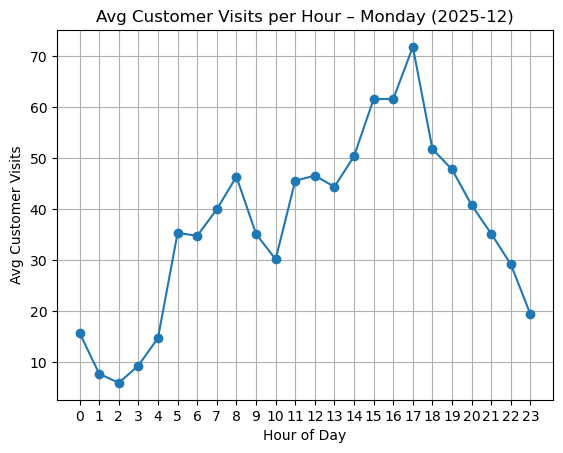

In [3]:
import matplotlib.pyplot as plt

# Choose month and weekday
month_to_view = "2025-12"
weekday_to_view = "Monday"

subset = combined[
    (combined["month"] == month_to_view) &
    (combined["weekday"] == weekday_to_view)
]

plt.figure()
plt.plot(subset["hour"], subset["avg_customer_visits"], marker="o")
plt.xlabel("Hour of Day")
plt.ylabel("Avg Customer Visits")
plt.title(f"Avg Customer Visits per Hour – {weekday_to_view} ({month_to_view})")
plt.xticks(range(0,24))
plt.grid(True)
plt.show()


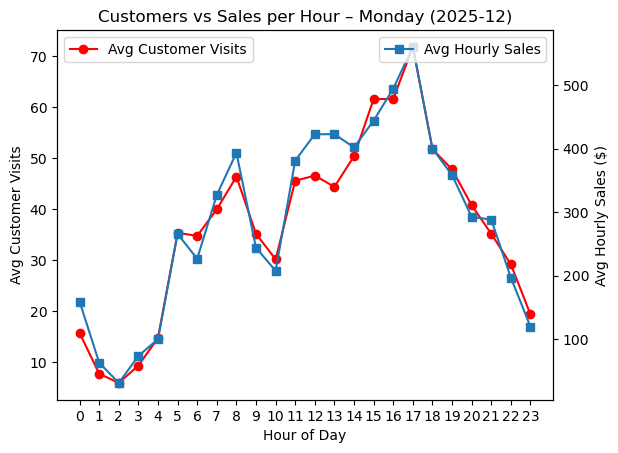

In [5]:
fig, ax1 = plt.subplots()

# Avg customer visits – RED line
ax1.plot(
    subset["hour"],
    subset["avg_customer_visits"],
    marker="o",
    color="red",
    label="Avg Customer Visits"
)
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Avg Customer Visits")

# Avg hourly sales – second axis
ax2 = ax1.twinx()
ax2.plot(
    subset["hour"],
    subset["avg_hourly_sales"],
    marker="s",
    label="Avg Hourly Sales"
)
ax2.set_ylabel("Avg Hourly Sales ($)")

# Title and ticks
plt.title(f"Customers vs Sales per Hour – {weekday_to_view} ({month_to_view})")
plt.xticks(range(0, 24))

# Optional: legends (recommended)
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.show()


In [6]:
df["is_weekend"] = df["weekday"].isin(["Saturday", "Sunday"])


In [7]:
daily_hourly = (
    df.groupby(
        ["month", "is_weekend", "sale_date", "hour"],
        as_index=False
    )
    .agg(
        hourly_sales=("Retail at Sale", "sum"),
        customer_visits=("Tran ID", "nunique")
    )
)


In [8]:
avg_weekday_weekend = (
    daily_hourly
    .groupby(["month", "is_weekend", "hour"], as_index=False)
    .agg(
        avg_hourly_sales=("hourly_sales", "mean"),
        avg_customer_visits=("customer_visits", "mean")
    )
)


In [9]:
avg_weekday_weekend["day_type"] = avg_weekday_weekend["is_weekend"].map(
    {False: "Weekday", True: "Weekend"}
)


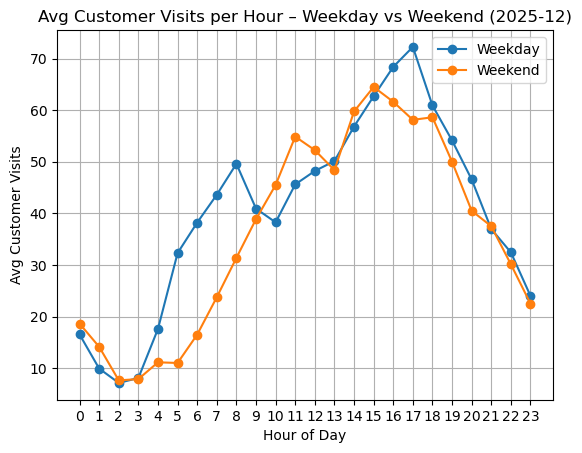

In [10]:
import matplotlib.pyplot as plt

month_to_view = "2025-12"
subset = avg_weekday_weekend[avg_weekday_weekend["month"] == month_to_view]

plt.figure()
for label in ["Weekday", "Weekend"]:
    temp = subset[subset["day_type"] == label]
    plt.plot(
        temp["hour"],
        temp["avg_customer_visits"],
        marker="o",
        label=label
    )

plt.xlabel("Hour of Day")
plt.ylabel("Avg Customer Visits")
plt.title(f"Avg Customer Visits per Hour – Weekday vs Weekend ({month_to_view})")
plt.xticks(range(0,24))
plt.legend()
plt.grid(True)
plt.show()


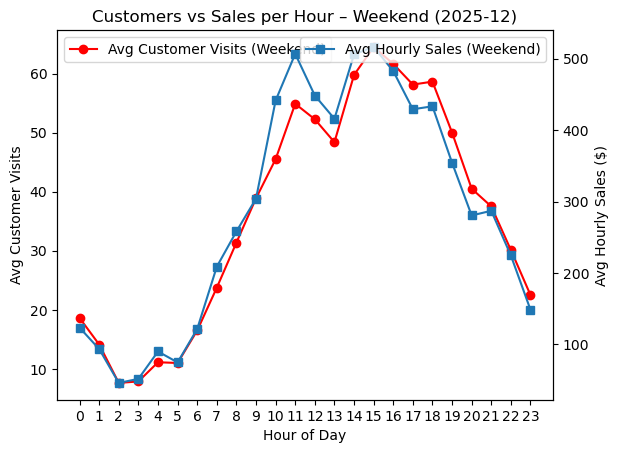

In [11]:
month_to_view = "2025-12"   # change if needed

weekend_subset = combined[
    (combined["month"] == month_to_view) &
    (combined["weekday"].isin(["Saturday", "Sunday"]))
]
weekend_avg = (
    weekend_subset
    .groupby("hour", as_index=False)
    .agg(
        avg_customer_visits=("avg_customer_visits", "mean"),
        avg_hourly_sales=("avg_hourly_sales", "mean")
    )
)
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# RED line: customers
ax1.plot(
    weekend_avg["hour"],
    weekend_avg["avg_customer_visits"],
    marker="o",
    color="red",
    label="Avg Customer Visits (Weekend)"
)
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Avg Customer Visits")
ax1.set_xticks(range(0, 24))

# BLUE line: sales
ax2 = ax1.twinx()
ax2.plot(
    weekend_avg["hour"],
    weekend_avg["avg_hourly_sales"],
    marker="s",
    label="Avg Hourly Sales (Weekend)"
)
ax2.set_ylabel("Avg Hourly Sales ($)")

# Legends
ax1.legend(loc="upper left")
ax2.legend(loc="upper right")

plt.title(f"Customers vs Sales per Hour – Weekend ({month_to_view})")
plt.show()

